<a href="https://colab.research.google.com/github/ujinew/data-analysis-study/blob/main/03_pandas_mini_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd

data = {
    "order_id": [1, 2, 3, 4, 5, 6],
    "customer": ["민지", "서준", "민지", "지우", "서준", "하윤"],
    "product": ["립밤", "토너", "크림", "토너", "립밤", "크림"],
    "quantity": [2, 1, 1, 3, 2, 1],
    "price": [12000, 18000, 35000, 18000, 12000, 35000]
}



In [37]:
df = pd.DataFrame(data)

df


,order_id,customer,product,quantity,price
0,1,민지,립밤,2,12000
1,2,서준,토너,1,18000
2,3,민지,크림,1,35000
3,4,지우,토너,3,18000
4,5,서준,립밤,2,12000
5,6,하윤,크림,1,35000


In [38]:
df["sales"] = df["quantity"] * df["price"]

df

,order_id,customer,product,quantity,price,sales
0,1,민지,립밤,2,12000,24000
1,2,서준,토너,1,18000,18000
2,3,민지,크림,1,35000,35000
3,4,지우,토너,3,18000,54000
4,5,서준,립밤,2,12000,24000
5,6,하윤,크림,1,35000,35000


In [39]:
df["quantity"]


,quantity
0,2
1,1
2,1
3,3
4,2
5,1


In [40]:
df["price"]

,price
0,12000
1,18000
2,35000
3,18000
4,12000
5,35000


In [41]:
df.head()

,order_id,customer,product,quantity,price,sales
0,1,민지,립밤,2,12000,24000
1,2,서준,토너,1,18000,18000
2,3,민지,크림,1,35000,35000
3,4,지우,토너,3,18000,54000
4,5,서준,립밤,2,12000,24000


In [42]:
df.shape

(6, 6)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  6 non-null      int64 
 1   customer  6 non-null      object
 2   product   6 non-null      object
 3   quantity  6 non-null      int64 
 4   price     6 non-null      int64 
 5   sales     6 non-null      int64 
dtypes: int64(4), object(2)
memory usage: 420.0+ bytes


In [44]:
df.isnull().sum()

,0
order_id,0
customer,0
product,0
quantity,0
price,0
sales,0


In [45]:
from numpy import ones
total_sales = df["sales"].sum()

print(f"전체 매출: {total_sales:,}원")


average_sales = df["sales"].mean()
print(f"평균 주문금액: {average_sales:,.0f}원")


product_sales = (
    df.groupby("product")["sales"]
    .sum()
    .reset_index()
)
product_sales = product_sales.sort_values(
    by="sales",
    ascending=False
)

product_sales

전체 매출: 190,000원
평균 주문금액: 31,667원


,product,sales
2,토너,72000
1,크림,70000
0,립밤,48000


In [24]:
product_quantity = (
    df.groupby("product")["quantity"]
    .sum()
    .reset_index()
)

product_quantity

product_quantity = product_quantity.sort_values(
    by="quantity",
    ascending=False
)
product_quantity

,product,quantity
0,립밤,4
2,토너,4
1,크림,2


In [25]:
customer_sales = (
    df.groupby("customer")["sales"]
    .sum()
    .reset_index()
)

customer_sales

customer_sales = customer_sales.sort_values(
    by="sales",
    ascending=False
)
customer_sales

,customer,sales
0,민지,59000
2,지우,54000
1,서준,42000
3,하윤,35000


In [35]:
customer_order_count = (
    df.groupby("customer")["order_id"]
    .count()
    .reset_index()
)

customer_order_count = customer_order_count.rename(
    columns={"order_id": "order_count"}
)

customer_order_count


,customer,order_count
0,민지,2
1,서준,2
2,지우,1
3,하윤,1


In [31]:
customer_analysis = pd.merge(
    customer_sales,
    customer_order_count,
    on="customer",
    how="left"
)


customer_analysis = customer_analysis.rename(
    columns={"order_id": "order_count"}
)

customer_analysis["average_order_value"] = (
    customer_analysis["sales"] /
    customer_analysis["order_count"]
)

customer_analysis

,customer,sales,order_count,average_order_value
0,민지,59000,2,29500.0
1,지우,54000,1,54000.0
2,서준,42000,2,21000.0
3,하윤,35000,1,35000.0


<Axes: xlabel='product'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47548 (\N{HANGUL SYLLABLE RIM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48164 (\N{HANGUL SYLLABLE BAM}) mis

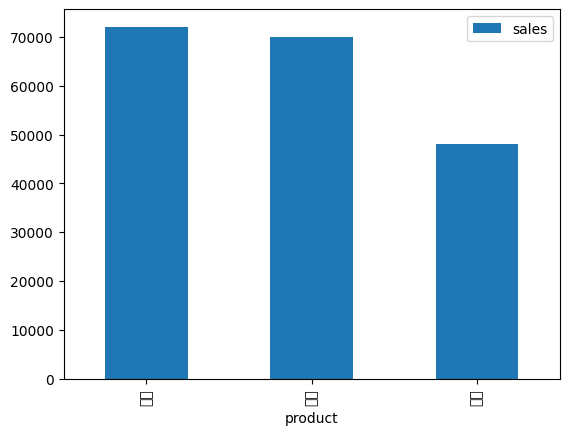

In [32]:
product_sales.plot(
    x="product",
    y="sales",
    kind="bar"
)

<Axes: xlabel='customer'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missin

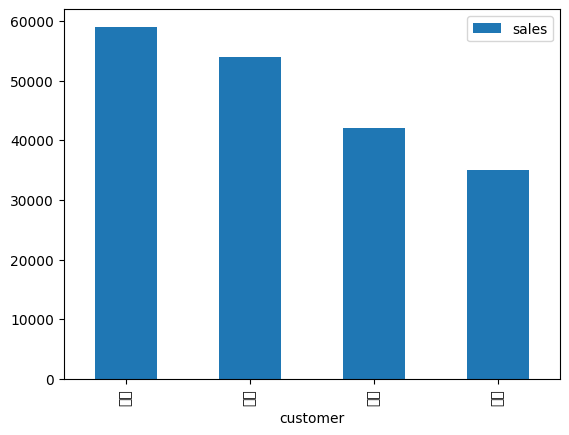

In [33]:
customer_sales.plot(
    x="customer",
    y="sales",
    kind="bar"
)


## 분석 결과

1. 전체 매출은 190,000원이며, 평균 주문금액은 약 31,667원이다.
2. 토너는 72,000원의 매출로 상품 중 가장 높은 매출을 기록했다.
3. 크림은 판매수량이 2개로 적었지만 높은 가격으로 인해 70,000원의 매출을 기록했다.
4. 립밤과 토너의 판매수량은 각각 4개로 같았지만, 가격 차이로 인해 토너의 매출이 더 높았다.
5. 민지는 총구매금액이 59,000원으로 가장 높은 고객이며, 지우는 평균 주문금액이 54,000원으로 가장 높았다.

- 크림은 판매수량이 많지 않았지만 높은 가격으로 인해 매출 기여도가 높았다.
- 토너는 판매수량이 많아 주요 판매 상품으로 볼 수 있었다.
- 민지는 주문 횟수와 총구매금액이 모두 높아 주요 고객으로 분류할 수 있다.

## 비즈니스 제안
※ 본 분석은 소규모 연습용 데이터를 사용했기 때문에, 실제 의사결정보다는 분석 방법을 익히는 데 목적이 있다.

1. 매출이 높은 크림은 재고 부족이 발생하지 않도록 안정적으로 관리한다.
2. 판매량이 높은 토너와 립밤은 묶음 상품이나 교차 판매를 활용한다.
3. 구매금액과 주문 횟수가 높은 고객에게 할인 쿠폰이나 재구매 혜택을 제공한다.
4. 구매 횟수는 많지만 평균 주문금액이 낮은 고객에게 세트 상품을 추천한다.